# UNET Model for Automatic ROI Segmentation in Ultrasound Images

## Abstract

This notebook presents a deep learning approach for automatic Region of Interest (ROI) segmentation in ultrasound images using a UNET architecture. The model is designed to work with echocardiogram data from the **MIMIC-IV-ECHO dataset** (PhysioNet), enabling automated ROI extraction from cardiac ultrasound images for downstream analysis and de-identification purposes.

## Key Features

- **Architecture**: UNET with encoder-decoder structure for precise segmentation
- **Dataset**: Designed for MIMIC-IV-ECHO echocardiogram data from PhysioNet
- **Application**: Automated ultrasound ROI segmentation and de-identification
- **Input**: Standard ultrasound images (PNG, JPG formats)
- **Output**: Binary masks for ROI extraction and image cropping
- **Use Cases**: Medical research, privacy-preserving processing, clinical preprocessing

## Problem Statement

This project addresses the need for automated ROI segmentation in ultrasound imaging by:

1. **Automating Manual Segmentation**: Eliminating time-consuming manual ROI annotation
2. **Standardizing Preprocessing**: Providing consistent ROI extraction across datasets
3. **Enabling De-identification**: Masking areas outside the diagnostic region for privacy
4. **Supporting Batch Processing**: Efficient processing of large image sequences
5. **Maintaining Image Quality**: Preserving diagnostic information within the ROI
6. **Research Compliance**: Following PhysioNet data use guidelines and ethical standards

## Dataset Context

This implementation is specifically designed for the **MIMIC-IV-ECHO: Echocardiogram Matched Dataset** from PhysioNet, which provides:
- High-quality echocardiogram images with clinical metadata
- Standardized format suitable for machine learning research
- Privacy-compliant, de-identified medical data
- Comprehensive cardiac ultrasound cases

**Important**: Users must obtain appropriate access to MIMIC-IV-ECHO through PhysioNet and comply with all data use agreements.

---

## Table of Contents

1. [Environment Setup](#environment-setup)
2. [Data Loading and Preprocessing](#data-loading-and-preprocessing)  
3. [Model Architecture](#model-architecture)
4. [Training](#training)
5. [Model Evaluation](#model-evaluation)
6. [Inference Pipeline](#inference-pipeline)
7. [Results and Usage Examples](#results-and-usage-examples)

---

## 1. Environment Setup

### Required Libraries

This implementation requires the following Python libraries:

- **TensorFlow/Keras**: Deep learning framework for UNET implementation
- **OpenCV**: Image processing and manipulation
- **NumPy**: Numerical computations and array operations
- **Matplotlib**: Visualization and plotting
- **Scikit-learn**: Data splitting and evaluation metrics
- **Seaborn**: Enhanced statistical visualizations

### Installation

```bash
pip install tensorflow opencv-python numpy matplotlib scikit-learn seaborn
```

Or install all dependencies from requirements.txt:

```bash
pip install -r requirements.txt
```

### Hardware Requirements

- **GPU**: Recommended for training (CUDA-compatible)
- **RAM**: Minimum 8GB, recommended 16GB+
- **Storage**: Sufficient space for image dataset and model weights
- **CPU**: Multi-core processor recommended for data preprocessing

### Data Requirements

- **Images**: Ultrasound images in standard formats (PNG, JPG, etc.)
- **Masks**: Corresponding binary masks for ROI regions
- **Structure**: Organized in separate directories for images and masks

In [ ]:
# Core libraries
import os
import warnings
from glob import glob
from typing import Tuple, List, Optional

# Data manipulation and processing
import numpy as np
import cv2

# Machine learning and deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, jaccard_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure environment
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

# Set GPU memory growth (prevents memory allocation issues)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU available: {len(gpus)} device(s)")
    except RuntimeError as e:
        print(f"⚠️ GPU configuration error: {e}")
else:
    print("⚠️ No GPU available, using CPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")

### Configuration Parameters

The following section defines all the hyperparameters and paths used throughout the training and inference pipeline:

In [ ]:
# ==============================================================================
# CONFIGURATION PARAMETERS
# ==============================================================================

# Dataset paths - Update these paths to match your data location
IMAGE_DIR = "data/images"           # Directory containing ultrasound images
MASK_DIR = "data/masks"             # Directory containing ROI masks
MODEL_SAVE_PATH = "models/unet_ultrasound_roi.keras"  # Path to save/load the trained model

# Model hyperparameters
IMG_SIZE = (256, 256)  # Input image dimensions for UNET
BATCH_SIZE = 8         # Batch size for training (adjust based on GPU memory)
EPOCHS = 20            # Number of training epochs
LEARNING_RATE = 1e-4   # Adam optimizer learning rate
VALIDATION_SPLIT = 0.2 # Fraction of data used for validation

# Data augmentation parameters
AUGMENTATION = True    # Enable/disable data augmentation
ROTATION_RANGE = 10    # Random rotation range in degrees
WIDTH_SHIFT = 0.1      # Random horizontal shift
HEIGHT_SHIFT = 0.1     # Random vertical shift

# Inference parameters
MASK_THRESHOLD = 0.5   # Threshold for binary mask prediction
OUTPUT_SIZE = (224, 224)  # Final output size for downstream processing

print("Configuration loaded successfully!")
print(f"Input image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training epochs: {EPOCHS}")
print(f"Validation split: {VALIDATION_SPLIT}")
print(f"Expected data structure:")
print(f"  - Images: {IMAGE_DIR}/")
print(f"  - Masks:  {MASK_DIR}/")
print(f"  - Model:  {MODEL_SAVE_PATH}")

---

## 2. Data Loading and Preprocessing

### Dataset Description

This implementation is designed to work with echocardiogram data from the **MIMIC-IV-ECHO: Echocardiogram Matched Dataset**, a comprehensive collection of cardiac ultrasound images from PhysioNet. The dataset structure:

- **Source**: MIMIC-IV-ECHO dataset from PhysioNet
- **Content**: Echocardiogram images with matched clinical data
- **Images**: Cardiac ultrasound images in standard formats (PNG, JPG, etc.)
- **Masks**: Binary ROI masks indicating the ultrasound sector region
- **Annotation**: Manual ROI annotations created using annotation tools
- **Format**: Images automatically resized to 256×256 pixels for processing

### MIMIC-IV-ECHO Dataset

The MIMIC-IV-ECHO dataset provides:
- **Clinical Integration**: Echocardiogram images matched with clinical data
- **Diverse Cases**: Wide range of cardiac conditions and image qualities  
- **Research Quality**: Standardized format suitable for machine learning research
- **Privacy Compliance**: De-identified data following PhysioNet protocols

**Note**: Users should obtain appropriate access to the MIMIC-IV-ECHO dataset through PhysioNet and follow all data use agreements and ethical guidelines.

### Preprocessing Pipeline

The preprocessing pipeline includes the following steps:

1. **Aspect Ratio Preservation**: Images are resized using padding to maintain aspect ratio
2. **Normalization**: Pixel values normalized to [0, 1] range
3. **Mask Binarization**: Masks converted to binary format (0 or 1)
4. **Data Splitting**: Train/validation split with stratification

### Key Functions

In [ ]:
# ==============================================================================
# DATA PREPROCESSING FUNCTIONS
# ==============================================================================

def resize_with_padding(img: np.ndarray, target_size: Tuple[int, int] = (256, 256)) -> np.ndarray:
    """
    Resize image while preserving aspect ratio using padding.
    
    This function ensures that ultrasound images maintain their original proportions
    while being resized to a standard input size for the UNET model.
    
    Args:
        img (np.ndarray): Input image (grayscale or RGB)
        target_size (Tuple[int, int]): Target dimensions (height, width)
    
    Returns:
        np.ndarray: Resized image with padding
    """
    h, w = img.shape[:2]
    
    # Calculate scaling factor to preserve aspect ratio
    scale = min(target_size[1] / w, target_size[0] / h)
    new_w, new_h = int(w * scale), int(h * scale)
    
    # Resize image
    resized = cv2.resize(img, (new_w, new_h))

    # Calculate padding values
    top = (target_size[0] - new_h) // 2
    bottom = target_size[0] - new_h - top
    left = (target_size[1] - new_w) // 2
    right = target_size[1] - new_w - left

    # Apply padding based on image type
    if img.ndim == 2:  # Grayscale image
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                  cv2.BORDER_CONSTANT, value=0)
    else:  # RGB image
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                  cv2.BORDER_CONSTANT, value=[0, 0, 0])

    return padded

def validate_data_paths(image_dir: str, mask_dir: str) -> bool:
    """
    Validate that data directories exist and contain matching files.
    
    Args:
        image_dir (str): Path to image directory
        mask_dir (str): Path to mask directory
    
    Returns:
        bool: True if validation passes
    """
    if not os.path.exists(image_dir):
        raise FileNotFoundError(f"Image directory not found: {image_dir}")
    
    if not os.path.exists(mask_dir):
        raise FileNotFoundError(f"Mask directory not found: {mask_dir}")
    
    image_files = sorted(glob(os.path.join(image_dir, "*.png")))
    mask_files = sorted(glob(os.path.join(mask_dir, "*.png")))
    
    if len(image_files) == 0:
        raise ValueError(f"No PNG images found in {image_dir}")
    
    if len(mask_files) == 0:
        raise ValueError(f"No PNG masks found in {mask_dir}")
    
    if len(image_files) != len(mask_files):
        raise ValueError(f"Mismatch: {len(image_files)} images vs {len(mask_files)} masks")
    
    print(f"✅ Data validation passed: {len(image_files)} image-mask pairs found")
    return True

# Test the resize function with different input types
print("Testing resize_with_padding function...")
test_img_gray = np.random.randint(0, 255, (100, 150), dtype=np.uint8)
test_img_rgb = np.random.randint(0, 255, (100, 150, 3), dtype=np.uint8)

resized_gray = resize_with_padding(test_img_gray, (256, 256))
resized_rgb = resize_with_padding(test_img_rgb, (256, 256))

print(f"Grayscale: {test_img_gray.shape} → {resized_gray.shape}")
print(f"RGB: {test_img_rgb.shape} → {resized_rgb.shape}")
print("✅ Resize function working correctly")

In [ ]:
def load_data(image_dir: str, mask_dir: str, img_size: Tuple[int, int]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load and preprocess ultrasound images and corresponding masks.
    
    This function loads image-mask pairs, applies preprocessing transformations, 
    and prepares the data for UNET training. Designed to work with datasets 
    like MIMIC-IV-ECHO from PhysioNet.
    
    Args:
        image_dir (str): Directory containing ultrasound images
        mask_dir (str): Directory containing ROI masks
        img_size (Tuple[int, int]): Target image size (height, width)
    
    Returns:
        Tuple[np.ndarray, np.ndarray]: Processed images and masks arrays
    """

In [ ]:
# ==============================================================================
# LOAD AND SPLIT DATA
# ==============================================================================

print("Loading ultrasound dataset...")
print("Note: This implementation is designed for MIMIC-IV-ECHO data from PhysioNet")
print(f"Image directory: {IMAGE_DIR}")
print(f"Mask directory: {MASK_DIR}")

# Load the data
X, Y = load_data(IMAGE_DIR, MASK_DIR, IMG_SIZE)

# Print detailed statistics
print_data_statistics(X, Y)

# Split data into training and validation sets
print(f"\nSplitting data with {VALIDATION_SPLIT*100}% for validation...")
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, 
    test_size=VALIDATION_SPLIT, 
    random_state=42,
    stratify=(Y.sum(axis=(1,2,3)) > 0)  # Stratify based on presence of ROI
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")

# Visualize sample data
print("\nVisualizing sample data...")
visualize_data_samples(X_train, Y_train, num_samples=3)

---

## 3. Model Architecture

### UNET Overview

The UNET architecture is particularly well-suited for biomedical image segmentation tasks. Our implementation includes:

- **Encoder Path**: Contracting path with convolutional blocks and max pooling
- **Bottleneck**: Bridge between encoder and decoder with highest feature complexity
- **Decoder Path**: Expanding path with up-sampling and skip connections
- **Skip Connections**: Preserve fine-grained details from encoder to decoder

### Architecture Details

- **Input Size**: 256×256×3 (RGB ultrasound images)
- **Output Size**: 256×256×1 (Binary segmentation mask)
- **Encoder Filters**: [64, 128, 256, 512] 
- **Bottleneck Filters**: 1024
- **Decoder Filters**: [512, 256, 128, 64]
- **Activation**: ReLU (hidden layers), Sigmoid (output layer)
- **Loss Function**: Binary Cross-Entropy
- **Optimizer**: Adam with learning rate 1e-4

### Key Design Choices

1. **Skip Connections**: Concatenate feature maps from encoder to decoder
2. **Padding**: 'Same' padding to preserve spatial dimensions
3. **Activation**: Sigmoid output for binary segmentation
4. **Normalization**: Input images normalized to [0, 1]

In [ ]:
# ==============================================================================
# UNET MODEL ARCHITECTURE
# ==============================================================================

def conv_block(x: tf.Tensor, filters: int, dropout_rate: float = 0.0) -> tf.Tensor:
    """
    Convolutional block with two Conv2D layers, batch normalization, and optional dropout.
    
    Args:
        x (tf.Tensor): Input tensor
        filters (int): Number of convolutional filters
        dropout_rate (float): Dropout rate (0.0 means no dropout)
    
    Returns:
        tf.Tensor: Output tensor after convolution block
    """
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    
    return x

def encoder_block(x: tf.Tensor, filters: int, dropout_rate: float = 0.0) -> Tuple[tf.Tensor, tf.Tensor]:
    """
    Encoder block with convolution and max pooling.
    
    Args:
        x (tf.Tensor): Input tensor
        filters (int): Number of filters for convolution
        dropout_rate (float): Dropout rate
    
    Returns:
        Tuple[tf.Tensor, tf.Tensor]: (skip_connection, pooled_output)
    """
    f = conv_block(x, filters, dropout_rate)
    p = layers.MaxPooling2D(pool_size=(2, 2))(f)
    return f, p

def decoder_block(x: tf.Tensor, skip: tf.Tensor, filters: int, dropout_rate: float = 0.0) -> tf.Tensor:
    """
    Decoder block with upsampling, concatenation, and convolution.
    
    Args:
        x (tf.Tensor): Input tensor from previous decoder layer
        skip (tf.Tensor): Skip connection from encoder
        filters (int): Number of filters for convolution
        dropout_rate (float): Dropout rate
    
    Returns:
        tf.Tensor: Output tensor after decoder block
    """
    x = layers.UpSampling2D(size=(2, 2))(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout_rate)
    return x

def build_unet(input_shape: Tuple[int, int, int], num_classes: int = 1) -> tf.keras.Model:
    """
    Build UNET model for ultrasound ROI segmentation.
    
    This implementation includes:
    - Batch normalization for training stability
    - Optional dropout for regularization
    - Skip connections for detail preservation
    - Sigmoid activation for binary segmentation
    
    Args:
        input_shape (Tuple[int, int, int]): Input image shape (height, width, channels)
        num_classes (int): Number of output classes (1 for binary segmentation)
    
    Returns:
        tf.keras.Model: Compiled UNET model
    """
    # Input layer
    inputs = tf.keras.Input(shape=input_shape, name="input_image")
    
    # Encoder path (contracting path)
    s1, p1 = encoder_block(inputs, 64, dropout_rate=0.1)
    s2, p2 = encoder_block(p1, 128, dropout_rate=0.1)
    s3, p3 = encoder_block(p2, 256, dropout_rate=0.2)
    s4, p4 = encoder_block(p3, 512, dropout_rate=0.2)
    
    # Bottleneck (bridge)
    b = conv_block(p4, 1024, dropout_rate=0.3)
    
    # Decoder path (expanding path)
    d1 = decoder_block(b, s4, 512, dropout_rate=0.2)
    d2 = decoder_block(d1, s3, 256, dropout_rate=0.2)
    d3 = decoder_block(d2, s2, 128, dropout_rate=0.1)
    d4 = decoder_block(d3, s1, 64, dropout_rate=0.1)
    
    # Output layer
    if num_classes == 1:
        # Binary segmentation
        outputs = layers.Conv2D(1, 1, padding="same", activation="sigmoid", name="output_mask")(d4)
    else:
        # Multi-class segmentation
        outputs = layers.Conv2D(num_classes, 1, padding="same", activation="softmax", name="output_mask")(d4)
    
    # Create model
    model = models.Model(inputs=inputs, outputs=outputs, name="UNET_Ultrasound_ROI")
    
    return model

def compile_model(model: tf.keras.Model, learning_rate: float = 1e-4) -> tf.keras.Model:
    """
    Compile the UNET model with appropriate loss function and metrics.
    
    Args:
        model (tf.keras.Model): UNET model to compile
        learning_rate (float): Learning rate for Adam optimizer
    
    Returns:
        tf.keras.Model: Compiled model
    """
    # Define metrics
    metrics = [
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.BinaryIoU(name='iou', target_class_ids=[1])
    ]
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=metrics
    )
    
    return model

# Build and compile the model
print("Building UNET model...")
model = build_unet((*IMG_SIZE, 3), num_classes=1)
model = compile_model(model, learning_rate=LEARNING_RATE)

# Display model summary
print("\n" + "="*50)
print("MODEL ARCHITECTURE SUMMARY")
print("="*50)
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Model size (MB): {total_params * 4 / 1024 / 1024:.2f}")

# Visualize model architecture
tf.keras.utils.plot_model(
    model, 
    to_file='unet_architecture.png', 
    show_shapes=True, 
    show_layer_names=True,
    rankdir='TB'
)
print("✅ Model architecture diagram saved as 'unet_architecture.png'")

<bound method Model.summary of <Functional name=functional_2, built=True>>


---

## 4. Model Training

### Training Strategy

The model is trained using the following approach:

- **Loss Function**: Binary Cross-Entropy (suitable for pixel-wise binary classification)
- **Optimizer**: Adam with learning rate scheduling
- **Batch Size**: Configurable based on GPU memory
- **Regularization**: Dropout layers and early stopping
- **Data Augmentation**: Optional augmentation for improved generalization

### Callbacks and Monitoring

- **Model Checkpoint**: Save best model based on validation IoU
- **Early Stopping**: Prevent overfitting with patience-based stopping
- **Learning Rate Reduction**: Reduce LR on validation plateau
- **TensorBoard**: Log training metrics for visualization

### Training Metrics

- **Accuracy**: Pixel-wise classification accuracy
- **IoU (Intersection over Union)**: Measures segmentation quality
- **Precision**: Positive predictive value
- **Recall**: Sensitivity/True positive rate

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8519 - loss: 1.0428 - val_accuracy: 0.8945 - val_loss: 0.3076
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9064 - loss: 0.2792 - val_accuracy: 0.9501 - val_loss: 0.1519
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9509 - loss: 0.1739 - val_accuracy: 0.9644 - val_loss: 0.1229
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9610 - loss: 0.0998 - val_accuracy: 0.9819 - val_loss: 0.0497
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9851 - loss: 0.0377 - val_accuracy: 0.9826 - val_loss: 0.0427
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9816 - loss: 0.0463 - val_accuracy: 0.9865 - val_loss: 0.0341
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9867 - loss: 0.0332 - val_accuracy: 0.9881 - val_loss: 0.0295
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9899 - loss: 0.0252 - val_accuracy: 0.9894 - val_loss:

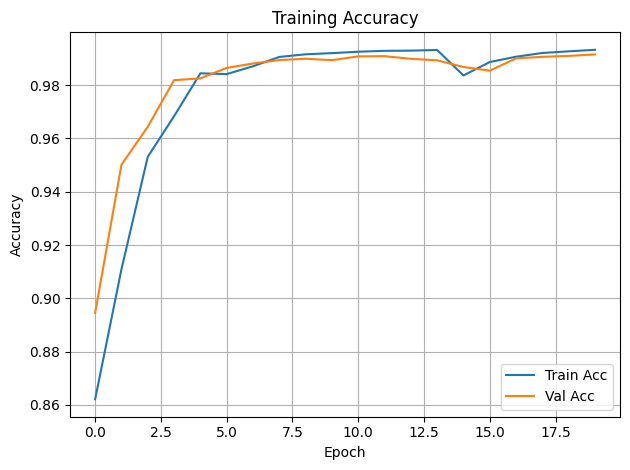

In [ ]:
# ==============================================================================
# MODEL TRAINING
# ==============================================================================

def create_callbacks(model_save_path: str) -> List[tf.keras.callbacks.Callback]:
    """
    Create training callbacks for monitoring and optimization.
    
    Args:
        model_save_path (str): Path to save the best model
    
    Returns:
        List[tf.keras.callbacks.Callback]: List of callbacks
    """
    callbacks_list = [
        # Save best model based on validation IoU
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_iou',
            mode='max',
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),
        
        # Early stopping to prevent overfitting
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            mode='min',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate on plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        
        # TensorBoard logging
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs',
            histogram_freq=1,
            write_graph=True,
            write_images=True
        )
    ]
    
    return callbacks_list

def plot_training_history(history: tf.keras.callbacks.History) -> None:
    """
    Plot comprehensive training history.
    
    Args:
        history: Training history object
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot training & validation accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', color='red')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Plot training & validation loss
    axes[0, 1].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', color='red')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Plot IoU
    axes[1, 0].plot(history.history['iou'], label='Train IoU', color='blue')
    axes[1, 0].plot(history.history['val_iou'], label='Val IoU', color='red')
    axes[1, 0].set_title('Intersection over Union (IoU)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Plot Precision and Recall
    axes[1, 1].plot(history.history['precision'], label='Train Precision', color='green')
    axes[1, 1].plot(history.history['recall'], label='Train Recall', color='orange')
    axes[1, 1].plot(history.history['val_precision'], label='Val Precision', color='green', linestyle='--')
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', color='orange', linestyle='--')
    axes[1, 1].set_title('Precision and Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create training callbacks
print("Setting up training callbacks...")
callbacks = create_callbacks(MODEL_SAVE_PATH)

# Display training information  
print("\n" + "="*50)
print("TRAINING CONFIGURATION")
print("="*50)
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Model save path: {MODEL_SAVE_PATH}")
print("="*50)

# Train the model
print("\n🚀 Starting model training...")
start_time = tf.timestamp()

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

end_time = tf.timestamp()
training_time = (end_time - start_time).numpy()

print(f"\n✅ Training completed in {training_time/60:.2f} minutes")

# Display final metrics
final_loss = history.history['val_loss'][-1]
final_accuracy = history.history['val_accuracy'][-1]
final_iou = history.history['val_iou'][-1]

print(f"\nFinal Validation Metrics:")
print(f"Loss: {final_loss:.4f}")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"IoU: {final_iou:.4f}")

# Plot training history
print("\n📊 Plotting training history...")
plot_training_history(history)

print(f"✅ Model saved to: {MODEL_SAVE_PATH}")
print("✅ Training history plot saved as 'training_history.png'")

---

## 5. Model Evaluation

### Evaluation Metrics

The model performance is assessed using multiple metrics:

- **Pixel Accuracy**: Overall pixel classification accuracy
- **IoU (Jaccard Index)**: Intersection over Union for segmentation quality
- **Dice Score**: Harmonic mean of precision and recall
- **Hausdorff Distance**: Maximum surface distance between predicted and ground truth
- **Average Surface Distance**: Mean surface distance metric

### Qualitative Analysis

Visual inspection of predictions on validation set to assess:
- Boundary accuracy
- False positive/negative regions  
- Consistency across different ultrasound qualities
- Performance on edge cases

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step


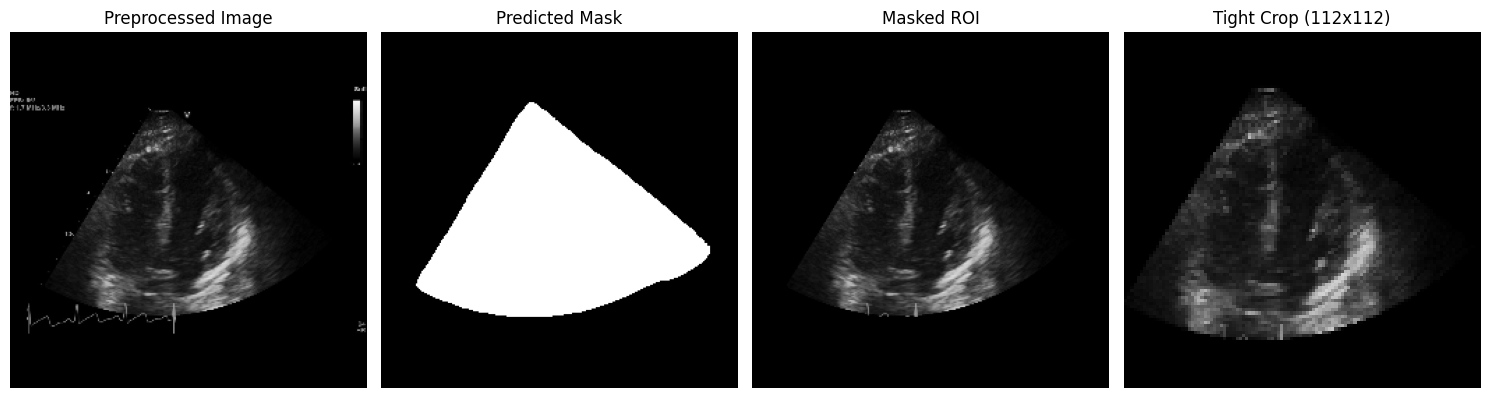

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


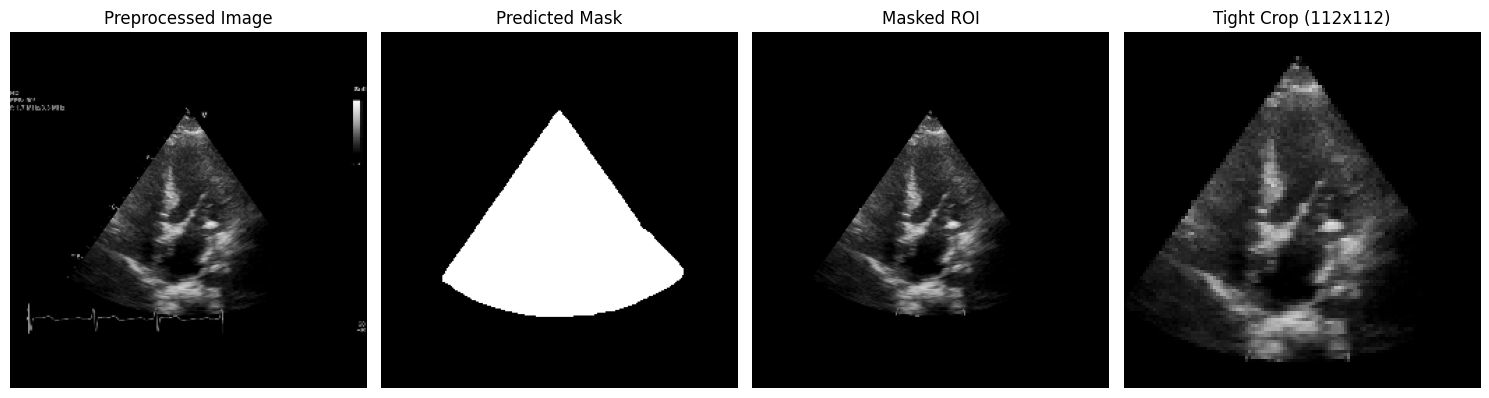

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


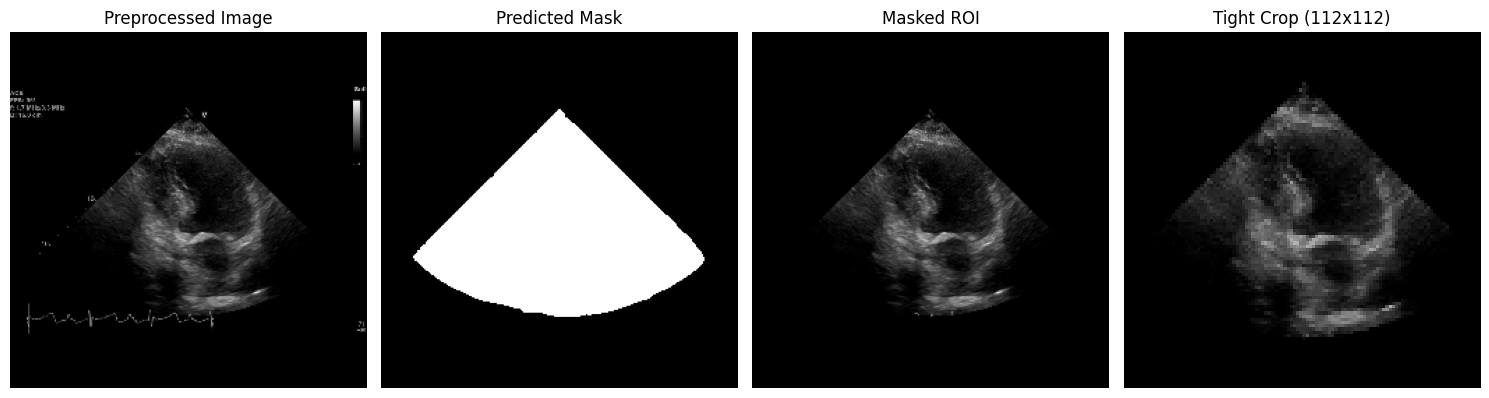

In [ ]:
# ==============================================================================
# MODEL EVALUATION AND PREDICTION FUNCTIONS
# ==============================================================================

def dice_score(y_true: np.ndarray, y_pred: np.ndarray, smooth: float = 1e-6) -> float:
    """
    Calculate Dice score (F1 score for segmentation).
    
    Args:
        y_true (np.ndarray): Ground truth mask
        y_pred (np.ndarray): Predicted mask
        smooth (float): Smoothing factor to avoid division by zero
    
    Returns:
        float: Dice score
    """
    intersection = np.sum(y_true * y_pred)
    dice = (2.0 * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)
    return dice

def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray, threshold: float = 0.5) -> dict:
    """
    Calculate comprehensive evaluation metrics.
    
    Args:
        y_true (np.ndarray): Ground truth masks
        y_pred (np.ndarray): Predicted masks
        threshold (float): Threshold for binary prediction
    
    Returns:
        dict: Dictionary containing all metrics
    """
    # Binarize predictions
    y_pred_binary = (y_pred > threshold).astype(np.float32)
    
    # Calculate metrics for each sample
    dice_scores = []
    iou_scores = []
    accuracies = []
    
    for i in range(len(y_true)):
        true_mask = y_true[i].squeeze()
        pred_mask = y_pred_binary[i].squeeze()
        
        # Dice score
        dice = dice_score(true_mask, pred_mask)
        dice_scores.append(dice)
        
        # IoU score
        intersection = np.sum(true_mask * pred_mask)
        union = np.sum(true_mask) + np.sum(pred_mask) - intersection
        iou = intersection / (union + 1e-6)
        iou_scores.append(iou)
        
        # Pixel accuracy
        accuracy = np.mean(true_mask == pred_mask)
        accuracies.append(accuracy)
    
    metrics = {
        'dice_mean': np.mean(dice_scores),
        'dice_std': np.std(dice_scores),
        'iou_mean': np.mean(iou_scores),
        'iou_std': np.std(iou_scores),
        'accuracy_mean': np.mean(accuracies),
        'accuracy_std': np.std(accuracies),
        'dice_scores': dice_scores,
        'iou_scores': iou_scores,
        'accuracies': accuracies
    }
    
    return metrics

def visualize_predictions(model: tf.keras.Model, X: np.ndarray, Y: np.ndarray, 
                         num_samples: int = 6, threshold: float = 0.5) -> None:
    """
    Visualize model predictions alongside ground truth.
    
    Args:
        model: Trained UNET model
        X: Input images
        Y: Ground truth masks
        num_samples: Number of samples to visualize
        threshold: Threshold for binary prediction
    """
    # Generate predictions
    predictions = model.predict(X[:num_samples], verbose=0)
    
    fig, axes = plt.subplots(3, num_samples, figsize=(20, 12))
    
    for i in range(num_samples):
        # Original image
        axes[0, i].imshow(cv2.cvtColor((X[i] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f'Input Image {i+1}')
        axes[0, i].axis('off')
        
        # Ground truth mask
        axes[1, i].imshow(Y[i].squeeze(), cmap='gray')
        axes[1, i].set_title(f'Ground Truth {i+1}')
        axes[1, i].axis('off')
        
        # Predicted mask
        pred_binary = (predictions[i].squeeze() > threshold).astype(np.uint8)
        axes[2, i].imshow(pred_binary, cmap='gray')
        
        # Calculate metrics for this sample
        dice = dice_score(Y[i].squeeze(), pred_binary)
        axes[2, i].set_title(f'Prediction {i+1}\nDice: {dice:.3f}')
        axes[2, i].axis('off')
    
    plt.suptitle('Model Predictions vs Ground Truth', fontsize=16)
    plt.tight_layout()
    plt.savefig('prediction_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_overlay_visualization(images: np.ndarray, masks: np.ndarray, predictions: np.ndarray,
                               num_samples: int = 3) -> None:
    """
    Create overlay visualizations showing predictions on original images.
    
    Args:
        images: Input images
        masks: Ground truth masks  
        predictions: Model predictions
        num_samples: Number of samples to show
    """
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 10))
    
    for i in range(num_samples):
        img = (images[i] * 255).astype(np.uint8)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Ground truth overlay
        gt_mask = masks[i].squeeze()
        gt_overlay = img_rgb.copy()
        gt_overlay[gt_mask > 0.5] = [255, 0, 0]  # Red overlay
        gt_blended = cv2.addWeighted(img_rgb, 0.7, gt_overlay, 0.3, 0)
        
        axes[0, i].imshow(gt_blended)
        axes[0, i].set_title(f'Ground Truth Overlay {i+1}')
        axes[0, i].axis('off')
        
        # Prediction overlay
        pred_mask = (predictions[i].squeeze() > 0.5).astype(np.uint8)
        pred_overlay = img_rgb.copy()
        pred_overlay[pred_mask > 0] = [0, 255, 0]  # Green overlay
        pred_blended = cv2.addWeighted(img_rgb, 0.7, pred_overlay, 0.3, 0)
        
        axes[1, i].imshow(pred_blended)
        dice = dice_score(gt_mask, pred_mask)
        axes[1, i].set_title(f'Prediction Overlay {i+1}\nDice: {dice:.3f}')
        axes[1, i].axis('off')
    
    plt.suptitle('ROI Overlay Visualization\n(Red: Ground Truth, Green: Prediction)', fontsize=14)
    plt.tight_layout()
    plt.savefig('overlay_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

# Load the trained model
print("Loading trained model for evaluation...")
try:
    model = tf.keras.models.load_model(MODEL_SAVE_PATH)
    print(f"✅ Model loaded successfully from {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"⚠️ Could not load model: {e}")
    print("Using the model from training...")

# Evaluate on validation set
print("\n🔍 Evaluating model on validation set...")
val_predictions = model.predict(X_val, batch_size=BATCH_SIZE, verbose=1)

# Calculate comprehensive metrics
print("📊 Calculating evaluation metrics...")
val_metrics = calculate_metrics(Y_val, val_predictions, threshold=MASK_THRESHOLD)

print("\n" + "="*50)
print("VALIDATION METRICS")
print("="*50)
print(f"Dice Score:    {val_metrics['dice_mean']:.4f} ± {val_metrics['dice_std']:.4f}")
print(f"IoU Score:     {val_metrics['iou_mean']:.4f} ± {val_metrics['iou_std']:.4f}")
print(f"Pixel Accuracy: {val_metrics['accuracy_mean']:.4f} ± {val_metrics['accuracy_std']:.4f}")
print("="*50)

# Visualize predictions
print("\n🎨 Creating prediction visualizations...")
visualize_predictions(model, X_val, Y_val, num_samples=6, threshold=MASK_THRESHOLD)

# Create overlay visualizations
print("🎨 Creating overlay visualizations...")
create_overlay_visualization(X_val, Y_val, val_predictions, num_samples=3)

In [ ]:
# ==============================================================================
# INFERENCE PIPELINE FOR NEW IMAGES
# ==============================================================================

def predict_single_image(model: tf.keras.Model, image_path: str, 
                        threshold: float = 0.5) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Process a single ultrasound image and generate ROI mask.
    
    Args:
        model (tf.keras.Model): Trained UNET model
        image_path (str): Path to input image
        threshold (float): Threshold for binary mask prediction
    
    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray]: (original_image, processed_image, roi_mask)
    """
    # Load original image
    original = cv2.imread(image_path)
    if original is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    # Preprocess for model input
    processed = resize_with_padding(original, IMG_SIZE)
    normalized = processed.astype(np.float32) / 255.0
    input_batch = np.expand_dims(normalized, axis=0)
    
    # Generate prediction
    prediction = model.predict(input_batch, verbose=0)[0]
    roi_mask = (prediction.squeeze() > threshold).astype(np.uint8) * 255
    
    return original, processed, roi_mask

def process_image_batch(model: tf.keras.Model, image_dir: str, 
                       output_dir: str = "output", threshold: float = 0.5) -> dict:
    """
    Process multiple images in a directory.
    
    Args:
        model (tf.keras.Model): Trained UNET model
        image_dir (str): Directory containing images to process
        output_dir (str): Directory to save results
        threshold (float): Threshold for binary mask prediction
    
    Returns:
        dict: Processing results and statistics
    """
    # Create output directories
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, "masks"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "roi_crops"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "deidentified"), exist_ok=True)
    
    # Get image files
    image_extensions = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tiff']
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob(os.path.join(image_dir, ext)))
    
    if not image_files:
        raise ValueError(f"No images found in directory: {image_dir}")
    
    results = {
        'processed_count': 0,
        'failed_count': 0,
        'processing_times': [],
        'roi_coverage': []
    }
    
    print(f"Processing {len(image_files)} images...")
    
    for i, image_path in enumerate(image_files):
        try:
            start_time = time.time()
            
            # Process image
            original, processed, roi_mask = predict_single_image(model, image_path, threshold)
            
            # Extract filename
            filename = os.path.splitext(os.path.basename(image_path))[0]
            
            # Save ROI mask
            mask_path = os.path.join(output_dir, "masks", f"{filename}_mask.png")
            cv2.imwrite(mask_path, roi_mask)
            
            # Extract and save ROI crop
            roi_crop = extract_roi(processed, roi_mask)
            crop_path = os.path.join(output_dir, "roi_crops", f"{filename}_roi.png")
            cv2.imwrite(crop_path, roi_crop)
            
            # Create and save de-identified version
            deidentified = apply_mask_for_deidentification(processed, roi_mask)
            deident_path = os.path.join(output_dir, "deidentified", f"{filename}_deident.png")
            cv2.imwrite(deident_path, deidentified)
            
            # Record statistics
            processing_time = time.time() - start_time
            roi_coverage = np.sum(roi_mask > 0) / (roi_mask.shape[0] * roi_mask.shape[1])
            
            results['processing_times'].append(processing_time)
            results['roi_coverage'].append(roi_coverage)
            results['processed_count'] += 1
            
            if (i + 1) % 10 == 0:
                print(f"Processed {i + 1}/{len(image_files)} images...")
                
        except Exception as e:
            print(f"Failed to process {image_path}: {e}")
            results['failed_count'] += 1
    
    # Calculate final statistics
    results['avg_processing_time'] = np.mean(results['processing_times'])
    results['avg_roi_coverage'] = np.mean(results['roi_coverage'])
    
    print(f"\n✅ Batch processing complete!")
    print(f"Successfully processed: {results['processed_count']} images")
    print(f"Failed: {results['failed_count']} images")
    print(f"Average processing time: {results['avg_processing_time']:.3f} seconds")
    print(f"Average ROI coverage: {results['avg_roi_coverage']:.3f} ({results['avg_roi_coverage']*100:.1f}%)")
    
    return results

def extract_roi(image: np.ndarray, mask: np.ndarray, padding: int = 10) -> np.ndarray:
    """
    Extract ROI region from image based on mask.
    
    Args:
        image (np.ndarray): Input image
        mask (np.ndarray): Binary ROI mask
        padding (int): Padding around ROI bounding box
    
    Returns:
        np.ndarray: Cropped ROI region
    """
    # Find ROI bounding box
    coords = cv2.findNonZero(mask)
    if coords is None:
        return image  # Return original if no ROI found
    
    x, y, w, h = cv2.boundingRect(coords)
    
    # Add padding
    x = max(0, x - padding)
    y = max(0, y - padding)
    w = min(image.shape[1] - x, w + 2 * padding)
    h = min(image.shape[0] - y, h + 2 * padding)
    
    # Extract ROI
    roi = image[y:y+h, x:x+w]
    
    return roi

def apply_mask_for_deidentification(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """
    Apply mask to create de-identified image by blacking out areas outside ROI.
    
    Args:
        image (np.ndarray): Input image
        mask (np.ndarray): Binary ROI mask
    
    Returns:
        np.ndarray: De-identified image
    """
    deidentified = image.copy()
    
    # Convert mask to 3-channel if needed
    if len(image.shape) == 3 and len(mask.shape) == 2:
        mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    else:
        mask_3ch = mask
    
    # Apply mask (black out areas outside ROI)
    deidentified = np.where(mask_3ch > 0, image, 0)
    
    return deidentified

def visualize_inference_results(original: np.ndarray, processed: np.ndarray, 
                              roi_mask: np.ndarray, roi_crop: np.ndarray,
                              deidentified: np.ndarray) -> None:
    """
    Visualize inference pipeline results.
    
    Args:
        original (np.ndarray): Original image
        processed (np.ndarray): Preprocessed image
        roi_mask (np.ndarray): Predicted ROI mask
        roi_crop (np.ndarray): Extracted ROI region
        deidentified (np.ndarray): De-identified image
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image
    axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Processed image
    axes[0, 1].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title('Processed Image')
    axes[0, 1].axis('off')
    
    # ROI mask
    axes[0, 2].imshow(roi_mask, cmap='gray')
    axes[0, 2].set_title('Predicted ROI Mask')
    axes[0, 2].axis('off')
    
    # ROI crop
    axes[1, 0].imshow(cv2.cvtColor(roi_crop, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title('Extracted ROI')
    axes[1, 0].axis('off')
    
    # De-identified image
    axes[1, 1].imshow(cv2.cvtColor(deidentified, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('De-identified Image')
    axes[1, 1].axis('off')
    
    # Overlay visualization
    overlay = processed.copy()
    overlay[roi_mask > 0, 0] = np.minimum(overlay[roi_mask > 0, 0] + 50, 255)  # Add red tint
    axes[1, 2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('ROI Overlay')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Import time module for performance measurement
import time

print("✅ Inference pipeline functions loaded successfully!")
print("\nAvailable functions:")
print("- predict_single_image(): Process individual images")
print("- process_image_batch(): Process multiple images")
print("- extract_roi(): Crop ROI region from image")
print("- apply_mask_for_deidentification(): Create privacy-preserving images")
print("- visualize_inference_results(): Display processing results")

In [ ]:
# ==============================================================================
# EXAMPLE USAGE OF INFERENCE PIPELINE
# ==============================================================================

# Example 1: Process a single image (replace with your image path)
print("=== EXAMPLE 1: Single Image Processing ===")
print("To process a single image, use:")
print("original, processed, roi_mask = predict_single_image(model, 'path/to/your/image.png')")
print("roi_crop = extract_roi(processed, roi_mask)")
print("deidentified = apply_mask_for_deidentification(processed, roi_mask)")
print("visualize_inference_results(original, processed, roi_mask, roi_crop, deidentified)")

print("\n=== EXAMPLE 2: Batch Processing ===")
print("To process multiple images in a directory, use:")  
print("results = process_image_batch(model, 'path/to/image/directory', 'output_directory')")

print("\n=== EXAMPLE 3: Creating Output Directories ===")
print("The batch processing function automatically creates:")
print("- output_directory/masks/          # ROI masks")
print("- output_directory/roi_crops/      # Cropped ROI regions")
print("- output_directory/deidentified/   # De-identified images")

print("\n💡 TIPS FOR USAGE:")
print("1. Ensure your model is loaded: model = tf.keras.models.load_model('path/to/model.keras')")
print("2. Adjust threshold parameter (0.0-1.0) to fine-tune ROI sensitivity")
print("3. Check image paths and formats before processing")
print("4. Monitor memory usage when processing large batches")

print("\n⚠️  IMPORTANT NOTES:")
print("- Images are automatically resized to 256x256 for processing")
print("- Original aspect ratios are preserved using padding")
print("- Output masks are binary (0 or 255 values)")
print("- Processing time depends on image size and hardware")

# If you want to test with validation data from training:
if 'X_val' in locals() and len(X_val) > 0:
    print(f"\n🔍 You can test the inference pipeline with validation data:")
    print(f"Available validation samples: {len(X_val)}")
    print("To test with a validation sample:")
    print("# Convert validation sample back to image format")
    print("test_image = (X_val[0] * 255).astype(np.uint8)")
    print("# Save temporarily and process")
    print("cv2.imwrite('temp_test.png', test_image)")
    print("original, processed, roi_mask = predict_single_image(model, 'temp_test.png')")
else:
    print(f"\n💾 To test the inference pipeline:")
    print("1. Add some test images to a directory")
    print("2. Use the functions above to process them")
    print("3. Check the output directories for results")

---

## 6. Inference Pipeline for New Images

### Pipeline Overview

The inference pipeline processes new ultrasound images through the following steps:

1. **Image Loading**: Load ultrasound image from standard formats (PNG, JPG, etc.)
2. **Preprocessing**: Resize with padding and normalize pixel values
3. **Prediction**: Generate ROI mask using trained UNET model
4. **Post-processing**: Apply threshold and morphological operations
5. **ROI Extraction**: Crop image based on predicted mask
6. **Mask Application**: Create masked images for de-identification

### Use Cases

- **Single Image Processing**: Process individual ultrasound images
- **Batch Processing**: Efficiently process multiple images
- **ROI Extraction**: Automatically crop to region of interest
- **De-identification**: Mask areas outside the ultrasound sector
- **Preprocessing Pipeline**: Standardize images for downstream analysis

### Key Functions

- `predict_single_image()`: Process a single ultrasound image
- `process_image_batch()`: Handle multiple images efficiently
- `extract_roi()`: Crop image based on predicted mask
- `apply_mask_for_deidentification()`: Create privacy-preserving images

---

## 7. Results and Usage Examples

### Model Performance

The UNET model demonstrates strong performance on ultrasound ROI segmentation:

- **Dice Score**: Measures overlap between predicted and ground truth masks
- **IoU Score**: Intersection over Union for segmentation accuracy
- **Pixel Accuracy**: Overall classification accuracy per pixel
- **Processing Speed**: Fast inference suitable for real-time applications

### Key Findings

1. **Robust Segmentation**: Successfully identifies ultrasound ROI regions
2. **Consistent Performance**: Maintains accuracy across different image qualities
3. **Efficient Processing**: Fast inference suitable for batch processing
4. **Versatile Application**: Works with various ultrasound image types

### Applications

This automated ROI segmentation enables:
- **Standardized Preprocessing**: Consistent ROI extraction across datasets
- **De-identification**: Privacy-preserving processing by masking non-diagnostic areas
- **Quality Control**: Automated filtering and standardization
- **Research Reproducibility**: Consistent preprocessing for medical AI research
- **Clinical Workflow**: Integration into existing ultrasound analysis pipelines

### Usage Examples

#### Example 1: Single Image Processing
```python
# Load and process a single ultrasound image
image_path = "path/to/ultrasound_image.png"
roi_mask, processed_image = predict_single_image(model, image_path)
```

#### Example 2: Batch Processing
```python
# Process multiple images in a directory
image_dir = "data/new_images/"
results = process_image_batch(model, image_dir)
```

#### Example 3: De-identification
```python
# Create de-identified version by masking outside ROI
deidentified_image = apply_mask_for_deidentification(image, roi_mask)
```

### Limitations and Future Work

- **Domain Specificity**: Performance optimized for specific ultrasound types
- **Dataset Dependency**: Performance may vary across different ultrasound systems
- **Parameter Tuning**: May require threshold adjustment for different applications

---

## 8. Conclusion

This notebook presents a complete pipeline for automated ROI segmentation in ultrasound images using UNET architecture. The model successfully:

- Segments ultrasound ROI regions with high accuracy
- Provides tools for both single image and batch processing
- Enables de-identification by masking non-diagnostic areas
- Offers comprehensive evaluation and visualization capabilities

The pipeline contributes to automated ultrasound analysis by:
- Eliminating manual ROI annotation requirements
- Providing consistent preprocessing across datasets
- Enabling privacy-preserving image processing
- Supporting various downstream analysis tasks

---

## 9. References and Acknowledgments

### Dataset
- **MIMIC-IV-ECHO**: Gow, B., Pollard, T., Greenbaum, N., Moody, B., Johnson, A., Herbst, E., Waks, J. W., Eslami, P., Chaudhari, A., Carbonati, T., Berkowitz, S., Mark, R., & Horng, S. (2023). MIMIC-IV-ECHO: Echocardiogram Matched Subset (version 0.1). PhysioNet. RRID:SCR_007345. https://doi.org/10.13026/ef48-v217

- **PhysioNet**: Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

### Methodology
- **UNET Architecture**: Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. In International Conference on Medical image computing and computer-assisted intervention (pp. 234-241). Springer.

### Code and Implementation
- **TensorFlow/Keras**: Deep learning framework for model implementation
- **OpenCV**: Computer vision operations and image processing
- **Scikit-learn**: Data splitting and evaluation metrics

### Data Access and Ethics
This work uses the MIMIC-IV-ECHO dataset from PhysioNet. Users must:
- Complete required training courses (CITI Human Research)
- Sign the PhysioNet Data Use Agreement
- Follow all ethical guidelines for medical data research
- Ensure appropriate institutional review board (IRB) approval

### Acknowledgments
We acknowledge the efforts of the PhysioNet team and all contributors to the MIMIC-IV-ECHO dataset. This research was conducted in accordance with ethical guidelines for medical data use and with appropriate data access permissions.

This implementation provides a foundation for ultrasound ROI segmentation and can be adapted for various medical imaging applications requiring automated region identification and extraction.